<a href="https://colab.research.google.com/github/Mat9408/An-lisedeDados_Distribuicao_de_Encomendas_no_DF/blob/main/M%C3%B3dulo_17_1%C2%BA_Projeto_Parte_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loggi: Análise de distribuição de encomendas pelo Distrito Federal

###Resumo: Exploração e avaliação sobre os dados disponibilizados pela empresa Loggi com objetivo de encontrar possíveis soluções para realizar a distribuição de encomendas pela região do Distrito Federal da melhor forma possível.

##Importação dos Pacotes e Bibliotecas

In [ ]:
!pip install geopandas;

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 61.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 88.1 MB/s eta 0:00:00


In [ ]:
import json
import pandas as pd
import geopandas
import seaborn as sns
import numpy as np
import geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import matplotlib.pyplot as plt

##Exploração de dados

###Coleta de dados

In [ ]:
!wget -q 'https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/deliveries.json' -O deliveries.json

In [ ]:
# Dado bruto em um dicionário:
with open('deliveries.json', mode='r', encoding='utf8') as file:
  data= json.load(file)

In [ ]:
# Dado bruto no Pandas:
deliveries_df= pd.DataFrame(data)

### Data Wrangling

In [ ]:
# "Flatten"(achatamento) da coluna origin e transformá-los numa nova coluna

hub_origin_df= pd.json_normalize(deliveries_df['origin'])
deliveries_df= pd.merge(left= deliveries_df, right= hub_origin_df, how='inner', left_index= True, right_index= True)
deliveries_df.head()

,name,region,origin,vehicle_capacity,deliveries,lng,lat
0,cvrp-2-df-33,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p...",-48.054989,-15.838145
1,cvrp-2-df-73,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po...",-48.054989,-15.838145
2,cvrp-2-df-20,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p...",-48.054989,-15.838145
3,cvrp-1-df-71,df-1,"{'lng': -47.89366206897872, 'lat': -15.8051175...",180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p...",-47.893662,-15.805118
4,cvrp-2-df-87,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p...",-48.054989,-15.838145


In [ ]:
# Remoção da coluna 'origin' e renomear as novas colunas lng e lat

deliveries_df= deliveries_df.drop('origin', axis=1)
deliveries_df.rename(columns={'lng': 'hub_lng', 'lat': 'hub_lat'}, inplace= True)
deliveries_df= deliveries_df[['name', 'region', 'hub_lng', 'hub_lat', 'vehicle_capacity', 'deliveries']]
deliveries_df.head()

,name,region,hub_lng,hub_lat,vehicle_capacity,deliveries
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p..."
1,cvrp-2-df-73,df-2,-48.054989,-15.838145,180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po..."
2,cvrp-2-df-20,df-2,-48.054989,-15.838145,180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p..."
3,cvrp-1-df-71,df-1,-47.893662,-15.805118,180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p..."
4,cvrp-2-df-87,df-2,-48.054989,-15.838145,180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p..."


In [ ]:
# Explosão da coluna 'deliveries'

deliveries_exploded_df= deliveries_df[['deliveries']].explode('deliveries')
deliveries_exploded_df.head()

,deliveries
0,"{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'po..."
0,"{'id': '320c94b17aa685c939b3f3244c3099de', 'po..."
0,"{'id': '3663b42f4b8decb33059febaba46d5c8', 'po..."
0,"{'id': 'e11ab58363c38d6abc90d5fba87b7d7', 'poi..."
0,"{'id': '54cb45b7bbbd4e34e7150900f92d7f4b', 'po..."


In [ ]:
# Manipulando o df 'deliveries_explode_df' preservando os índices e alterando o nome das colunas

deliveries_normalized_df= pd.concat([
    pd.DataFrame(deliveries_exploded_df['deliveries'].apply(lambda record: record['size'])).rename(columns={'deliveries': 'delivery_size'}),
    pd.DataFrame(deliveries_exploded_df['deliveries'].apply(lambda record: record['point']['lng'])).rename(columns={'deliveries': 'delivery_lng'}),
    pd.DataFrame(deliveries_exploded_df['deliveries'].apply(lambda record: record['point']['lat'])).rename(columns={'deliveries': 'delivery_lat'}),
], axis= 1)
deliveries_normalized_df.head()

,delivery_size,delivery_lng,delivery_lat
0,9,-48.116189,-15.848929
0,2,-48.118195,-15.850772
0,1,-48.112483,-15.847871
0,2,-48.118023,-15.846471
0,7,-48.114898,-15.858055


In [ ]:
# Remoção da coluna deliveries e merge com o DataFrame original (deliveries_df)

deliveries_df= deliveries_df.drop('deliveries', axis= 1)
deliveries_df= pd.merge(left= deliveries_df, right= deliveries_normalized_df, how= 'right', left_index= True, right_index= True)
deliveries_df.reset_index(inplace= True, drop= True)
deliveries_df.head()

,name,region,hub_lng,hub_lat,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,9,-48.116189,-15.848929
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118195,-15.850772
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,1,-48.112483,-15.847871
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118023,-15.846471
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,7,-48.114898,-15.858055


###Estrutura dos Dados

In [ ]:
deliveries_df.head()

,name,region,hub_lng,hub_lat,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,9,-48.116189,-15.848929
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118195,-15.850772
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,1,-48.112483,-15.847871
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118023,-15.846471
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,7,-48.114898,-15.858055


In [ ]:
deliveries_df.index

RangeIndex(start=0, stop=636149, step=1)

In [ ]:
deliveries_df.columns

Index(['name', 'region', 'hub_lng', 'hub_lat', 'vehicle_capacity',
       'delivery_size', 'delivery_lng', 'delivery_lat'],
      dtype='object')

In [ ]:
deliveries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636149 entries, 0 to 636148
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              636149 non-null  object 
 1   region            636149 non-null  object 
 2   hub_lng           636149 non-null  float64
 3   hub_lat           636149 non-null  float64
 4   vehicle_capacity  636149 non-null  int64  
 5   delivery_size     636149 non-null  int64  
 6   delivery_lng      636149 non-null  float64
 7   delivery_lat      636149 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 38.8+ MB


###Exploração do Schema

##Manipulação dos dados

In [ ]:
# DataFrame dos endereços dos Hub's da Loggi:

hub_df= deliveries_df[['region', 'hub_lng', 'hub_lat']]
hub_df= hub_df.drop_duplicates().sort_values(by='region').reset_index(drop= True)
hub_df.head()

,region,hub_lng,hub_lat
0,df-0,-47.802665,-15.657014
1,df-1,-47.893662,-15.805118
2,df-2,-48.054989,-15.838145


In [ ]:
# Geocodificação Reversa dos Endereços dos Hub's de entrega da Loggi:

geolocator= Nominatim(user_agent='ebac_geocoder', timeout=1000)
location= geolocator.reverse("-15.657013854445248, -47.802664728268745")

print(json.dumps(location.raw, indent=2, ensure_ascii= False))

geocoder= RateLimiter(geolocator.reverse, min_delay_seconds= 1)


{
  "place_id": 68906480,
  "licence": "Data © OpenStreetMap contributors, ODbL 1.0. https://osm.org/copyright",
  "osm_type": "node",
  "osm_id": 6456379935,
  "lat": "-15.656819",
  "lon": "-47.8019514",
  "display_name": "Clinica dos Olhos, Rua 7, Quadra 2, Sobradinho, Região Geográfica Imediata do Distrito Federal, Região Integrada de Desenvolvimento do Distrito Federal e Entorno, Região Geográfica Intermediária do Distrito Federal, Distrito Federal, Região Centro-Oeste, 73015-202, Brasil",
  "address": {
    "amenity": "Clinica dos Olhos",
    "road": "Rua 7",
    "residential": "Quadra 2",
    "suburb": "Sobradinho",
    "town": "Sobradinho",
    "municipality": "Região Geográfica Imediata do Distrito Federal",
    "county": "Região Integrada de Desenvolvimento do Distrito Federal e Entorno",
    "state_district": "Região Geográfica Intermediária do Distrito Federal",
    "state": "Distrito Federal",
    "ISO3166-2-lvl4": "BR-DF",
    "region": "Região Centro-Oeste",
    "postcod

In [ ]:
# Criando as colunas 'coordinates' e 'geodata no DataFrame 'hub_df':

hub_df['coordinates']= hub_df['hub_lat'].astype(str) + ', ' + hub_df['hub_lng'].astype(str)
hub_df['geodata']= hub_df['coordinates'].apply(geocoder)
hub_df.head()

,region,hub_lng,hub_lat,coordinates,geodata
0,df-0,-47.802665,-15.657014,"-15.657013854445248, -47.802664728268745","(Clinica dos Olhos, Rua 7, Quadra 2, Sobradinh..."
1,df-1,-47.893662,-15.805118,"-15.80511751066334, -47.89366206897872","(Bloco B / F, W1 Sul, SQS 103, Asa Sul, Brasíl..."
2,df-2,-48.054989,-15.838145,"-15.83814451122274, -48.05498915846707","(Armazém do Bolo, lote 4/8, CSB 4/5, Taguating..."


In [ ]:
# 'normalize' na coluna geodata separando todas as informações:

hub_geodata_df= pd.json_normalize(hub_df['geodata'].apply(lambda data: data.raw))
hub_geodata_df.head()

,place_id,licence,osm_type,osm_id,lat,lon,display_name,boundingbox,address.amenity,address.road,...,address.ISO3166-2-lvl4,address.region,address.postcode,address.country,address.country_code,address.building,address.neighbourhood,address.city,address.shop,address.house_number
0,68906480,"Data © OpenStreetMap contributors, ODbL 1.0. h...",node,6456379935,-15.656819,-47.8019514,"Clinica dos Olhos, Rua 7, Quadra 2, Sobradinho...","[-15.656869, -15.656769, -47.8020014, -47.8019...",Clinica dos Olhos,Rua 7,...,BR-DF,Região Centro-Oeste,73015-202,Brasil,br,NaN,NaN,NaN,NaN,NaN
1,138610967,"Data © OpenStreetMap contributors, ODbL 1.0. h...",way,140908717,-15.80443735,-47.893155456691616,"Bloco B / F, W1 Sul, SQS 103, Asa Sul, Brasíli...","[-15.805071, -15.8038038, -47.8937468, -47.892...",NaN,W1 Sul,...,BR-DF,Região Centro-Oeste,70342-010,Brasil,br,Bloco B / F,SQS 103,Brasília,NaN,NaN
2,67585484,"Data © OpenStreetMap contributors, ODbL 1.0. h...",node,6249717596,-15.8384371,-48.0552917,"Armazém do Bolo, lote 4/8, CSB 4/5, Taguatinga...","[-15.8384871, -15.8383871, -48.0553417, -48.05...",NaN,CSB 4/5,...,BR-DF,Região Centro-Oeste,72015-030,Brasil,br,NaN,NaN,Taguatinga,Armazém do Bolo,lote 4/8


In [ ]:
# Selecionando, alterando nomes e organizando as informações de endereço:

hub_geodata_df= hub_geodata_df[['address.town', 'address.suburb', 'address.city', 'address.postcode', 'address.road', 'address.house_number']]
hub_geodata_df.rename(columns={'address.town': 'hub_town', 'address.suburb': 'hub_suburb', 'address.city': 'hub_city', 'address.postcode':'hub_postcode', 'address.road': 'hub_road', 'address.house_number': 'hub_number'}, inplace= True)
hub_geodata_df['hub_city']= np.where(hub_geodata_df['hub_city'].notna(), hub_geodata_df['hub_city'],hub_geodata_df['hub_town'])
hub_geodata_df['hub_suburb']= np.where(hub_geodata_df['hub_suburb'].notna(), hub_geodata_df['hub_suburb'], hub_geodata_df['hub_city'])
hub_geodata_df= hub_geodata_df.drop('hub_town', axis= 1)
hub_geodata_df.head()

<ipython-input-20-935663aacc23>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hub_geodata_df.rename(columns={'address.town': 'hub_town', 'address.suburb': 'hub_suburb', 'address.city': 'hub_city', 'address.postcode':'hub_postcode', 'address.road': 'hub_road', 'address.house_number': 'hub_number'}, inplace= True)
<ipython-input-20-935663aacc23>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hub_geodata_df['hub_city']= np.where(hub_geodata_df['hub_city'].notna(), hub_geodata_df['hub_city'],hub_geodata_df['hub_town'])
<ipython-input-20-935663aacc23>:6: SettingW

,hub_suburb,hub_city,hub_postcode,hub_road,hub_number
0,Sobradinho,Sobradinho,73015-202,Rua 7,NaN
1,Asa Sul,Brasília,70342-010,W1 Sul,NaN
2,Taguatinga,Taguatinga,72015-030,CSB 4/5,lote 4/8


In [ ]:
# Merge dos DataFrames 'hub_df' e 'hub_geodata_df'

hub_df= pd.merge(left= hub_df, right= hub_geodata_df, left_index= True, right_index= True)
hub_df= hub_df[['region', 'hub_suburb', 'hub_city', 'hub_postcode', 'hub_road', 'hub_number']]
hub_df.head()

,region,hub_suburb,hub_city,hub_postcode,hub_road,hub_number
0,df-0,Sobradinho,Sobradinho,73015-202,Rua 7,NaN
1,df-1,Asa Sul,Brasília,70342-010,W1 Sul,NaN
2,df-2,Taguatinga,Taguatinga,72015-030,CSB 4/5,lote 4/8


In [ ]:
# Merge com o DataFrame principal 'deliveries_df'

deliveries_df= pd.merge(left= deliveries_df, right= hub_df, how= 'inner', on='region')
deliveries_df= deliveries_df[['name', 'region', 'hub_lng', 'hub_lat', 'hub_postcode', 'hub_road', 'hub_number', 'hub_city', 'hub_suburb', 'vehicle_capacity', 'delivery_size', 'delivery_lng', 'delivery_lat']]
deliveries_df.head()

,name,region,hub_lng,hub_lat,hub_postcode,hub_road,hub_number,hub_city,hub_suburb,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,9,-48.116189,-15.848929
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,2,-48.118195,-15.850772
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,1,-48.112483,-15.847871
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,2,-48.118023,-15.846471
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,7,-48.114898,-15.858055


In [ ]:
!wget -q "https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/deliveries-geodata.csv" -O deliveries-geodata.csv

In [ ]:
# Carregar o DataFrame geodata dos endereços de entrega 'deliveries'
deliveries_geodata_df= pd.read_csv('deliveries-geodata.csv')
deliveries_geodata_df.head()

,delivery_lng,delivery_lat,delivery_city,delivery_suburb
0,-48.116189,-15.848929,Ceilândia,P Sul
1,-48.118195,-15.850772,Ceilândia,P Sul
2,-48.112483,-15.847871,Ceilândia,P Sul
3,-48.118023,-15.846471,Ceilândia,P Sul
4,-48.114898,-15.858055,Sol Nascente/Pôr do Sol,Sol Nascente/Pôr do Sol


In [ ]:
deliveries_df= pd.merge(left= deliveries_df, right= deliveries_geodata_df[['delivery_city', 'delivery_suburb']], how= 'inner', left_index= True, right_index= True)
deliveries_df.head()

,name,region,hub_lng,hub_lat,hub_postcode,hub_road,hub_number,hub_city,hub_suburb,vehicle_capacity,delivery_size,delivery_lng,delivery_lat,delivery_city,delivery_suburb
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,9,-48.116189,-15.848929,Ceilândia,P Sul
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,2,-48.118195,-15.850772,Ceilândia,P Sul
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,1,-48.112483,-15.847871,Ceilândia,P Sul
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,2,-48.118023,-15.846471,Ceilândia,P Sul
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,7,-48.114898,-15.858055,Sol Nascente/Pôr do Sol,Sol Nascente/Pôr do Sol


###Qualidade dos dados manipulados

In [ ]:
# Informações gerais sobre o DataFrame principal 'deliveries_df'
deliveries_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 636149 entries, 0 to 636148
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              636149 non-null  object 
 1   region            636149 non-null  object 
 2   hub_lng           636149 non-null  float64
 3   hub_lat           636149 non-null  float64
 4   hub_postcode      636149 non-null  object 
 5   hub_road          636149 non-null  object 
 6   hub_number        261319 non-null  object 
 7   hub_city          636149 non-null  object 
 8   hub_suburb        636149 non-null  object 
 9   vehicle_capacity  636149 non-null  int64  
 10  delivery_size     636149 non-null  int64  
 11  delivery_lng      636149 non-null  float64
 12  delivery_lat      636149 non-null  float64
 13  delivery_city     634447 non-null  object 
 14  delivery_suburb   476264 non-null  object 
dtypes: float64(4), int64(2), object(9)
memory usage: 93.8+ MB


In [ ]:
# Informações sobre as colunas que há valores nulos:
deliveries_df.isna().any()

name                False
region              False
hub_lng             False
hub_lat             False
hub_postcode        False
hub_road            False
hub_number           True
hub_city            False
hub_suburb          False
vehicle_capacity    False
delivery_size       False
delivery_lng        False
delivery_lat        False
delivery_city        True
delivery_suburb      True
dtype: bool

In [ ]:
# Porcentagem de valores nulos de cidades nos endereços de entrega:
100 * (deliveries_df['delivery_city'].isna().sum() / len(deliveries_df))

0.26754738276724477

In [ ]:
# Porcentagem de valores nulos dos bairros nos endereços de entrega (suburb):
100*(deliveries_df['delivery_suburb'].isna().sum() / len(deliveries_df))

25.133262804783158

In [ ]:
# Porcentagem do número de entregas por bairros:
prop_df= deliveries_df[['delivery_suburb']].value_counts() / len(deliveries_df)
prop_df.sort_values(ascending= False).head(10)

delivery_suburb 
Brasília            0.084564
Asa Norte           0.076639
Taguatinga          0.063363
Asa Sul             0.059263
Águas Claras        0.056598
Guará               0.055619
Samambaia           0.026514
Sobradinho          0.018148
Recanto das Emas    0.015029
P Sul               0.012807
dtype: float64

- Importante ressaltar que Brasília não é um bairro. Nesse caso pode reduzir a precisão das informações finais mas, contribui para uma visão primária.

##Visualização

In [ ]:
# Download da base cartográfica do Distrito Federal e conversão para .shp:

!wget -q "https://geoftp.ibge.gov.br/cartas_e_mapas/bases_cartograficas_continuas/bc100/go_df/versao2016/shapefile/bc100_go_df_shp.zip" -O distrito-federal.zip
!unzip -q distrito-federal.zip -d ./maps
!cp ./maps/LIM_Unidade_Federacao_A.shp ./distrito-federal.shp
!cp ./maps/LIM_Unidade_Federacao_A.shx ./distrito-federal.shx

In [ ]:
# Leitura do mapa:

mapa= geopandas.read_file('distrito-federal.shp')
mapa= mapa.loc[[0]]
mapa.head()

,geometry
0,"POLYGON Z ((-47.31048 -16.03602 0.00000, -47.3..."


In [ ]:
# Pontos dos Hub's (coluna 'geometry'): Criação do DataFrame 'geo_hub_df através do DataFrame deliveries_df:

hub_df= deliveries_df[['region', 'hub_lng', 'hub_lat']].drop_duplicates().reset_index(drop= True)
geo_hub_df= geopandas.GeoDataFrame(hub_df, geometry= geopandas.points_from_xy(hub_df['hub_lng'], hub_df['hub_lat']))
geo_hub_df.head()

,region,hub_lng,hub_lat,geometry
0,df-2,-48.054989,-15.838145,POINT (-48.05499 -15.83814)
1,df-1,-47.893662,-15.805118,POINT (-47.89366 -15.80512)
2,df-0,-47.802665,-15.657014,POINT (-47.80266 -15.65701)


In [ ]:
# Adição dos pontos dos hub's (geometry) ao DataFrame principal (delideries_df):

geo_deliveries_df= geopandas.GeoDataFrame(deliveries_df, geometry= geopandas.points_from_xy(deliveries_df['delivery_lng'], deliveries_df['delivery_lat']))
geo_deliveries_df.head()

,name,region,hub_lng,hub_lat,hub_postcode,hub_road,hub_number,hub_city,hub_suburb,vehicle_capacity,delivery_size,delivery_lng,delivery_lat,delivery_city,delivery_suburb,geometry
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,9,-48.116189,-15.848929,Ceilândia,P Sul,POINT (-48.11619 -15.84893)
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,2,-48.118195,-15.850772,Ceilândia,P Sul,POINT (-48.11819 -15.85077)
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,1,-48.112483,-15.847871,Ceilândia,P Sul,POINT (-48.11248 -15.84787)
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,2,-48.118023,-15.846471,Ceilândia,P Sul,POINT (-48.11802 -15.84647)
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,72015-030,CSB 4/5,lote 4/8,Taguatinga,Taguatinga,180,7,-48.114898,-15.858055,Sol Nascente/Pôr do Sol,Sol Nascente/Pôr do Sol,POINT (-48.11490 -15.85805)


<ipython-input-35-0c06fde7137d>:20: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in lgnd.legendHandles:


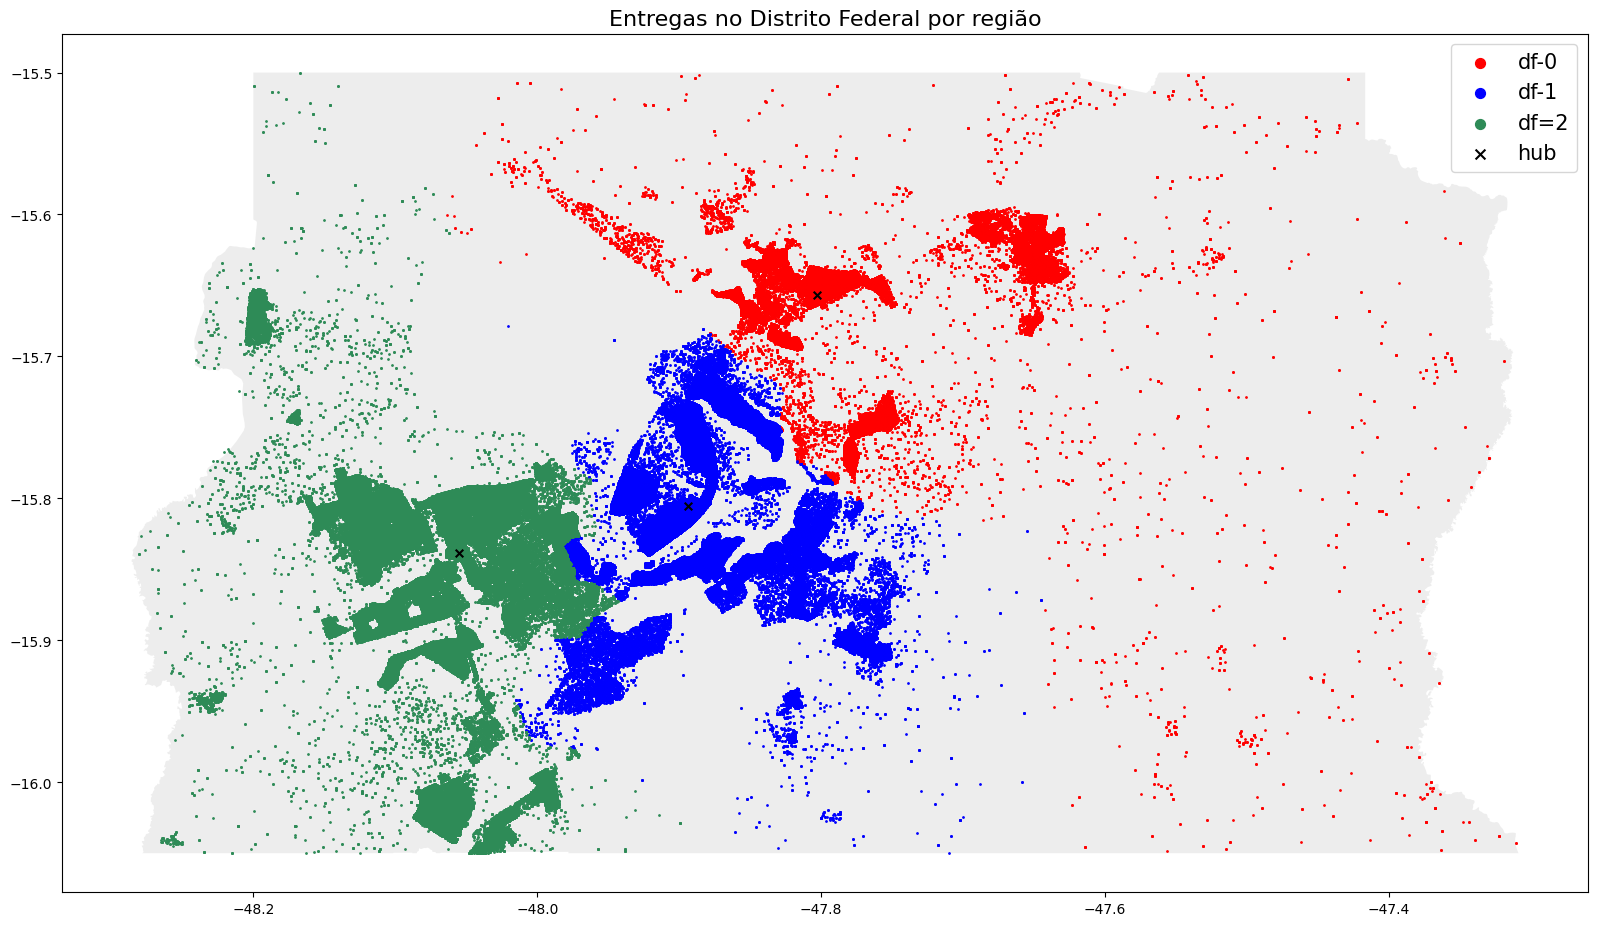

In [ ]:
# Visualização do mapa:

# Cria o plot vazio:
fig, ax= plt.subplots(figsize= (50/2.54, 50/2.54))

# Plot mapa do Distrito Federal:
mapa.plot(ax=ax, alpha= 0.4, color= 'lightgrey')

# Plot das entregas separadas por suas regiões:
geo_deliveries_df.query("region == 'df-0'").plot(ax=ax, markersize= 1, color= 'red', label= 'df-0')
geo_deliveries_df.query("region == 'df-1'").plot(ax=ax, markersize= 1, color= 'blue', label= 'df-1')
geo_deliveries_df.query("region == 'df-2'").plot(ax=ax, markersize= 1, color= 'seagreen', label= 'df=2')

# Plot de localização dos Hub's:
geo_hub_df.plot(ax=ax, markersize= 30, marker= 'x', color= 'black', label= 'hub')

# Plot da legenda:
plt.title('Entregas no Distrito Federal por região', fontdict={'fontsize':16})
lgnd= plt.legend(prop={'size': 15})
for handle in lgnd.legendHandles:
  handle.set_sizes([50])

##Análises e Visualizações Gráficas

- Quais regiões possuem mais entregas a serem feitas?

In [ ]:
deliveries_per_region= deliveries_df[['region']].value_counts()
print(deliveries_per_region)

region
df-1      304708
df-2      261319
df-0       70122
dtype: int64


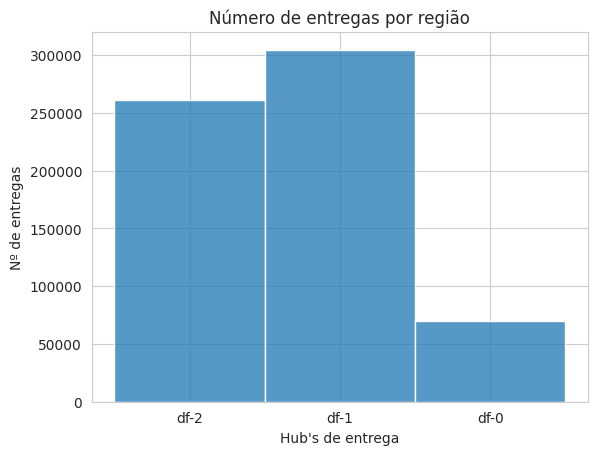

In [ ]:
deliveries_per_region_hist= deliveries_df[['region']]

with sns.axes_style('whitegrid'):
  grafico= sns.histplot(data=deliveries_df, x='region')
  grafico.set(title='Número de entregas por região', xlabel= "Hub's de entrega", ylabel= 'Nº de entregas')

- Média de entregas por região:

In [ ]:
data= pd.DataFrame(deliveries_df[['region', 'vehicle_capacity']].value_counts(normalize= True)).reset_index()
data.rename(columns={0: 'region_percent'}, inplace= True)
data.head()

,region,vehicle_capacity,region_percent
0,df-1,180,0.478988
1,df-2,180,0.410783
2,df-0,180,0.110229


<ipython-input-39-f0b5e81bbbe3>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  grafico= sns.barplot(data=data, x='region', y='region_percent', ci= None, palette='pastel')


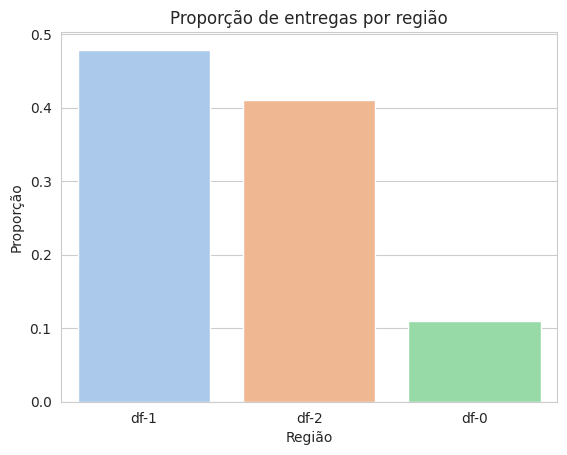

In [ ]:
with sns.axes_style('whitegrid'):
  grafico= sns.barplot(data=data, x='region', y='region_percent', ci= None, palette='pastel')
  grafico.set(title='Proporção de entregas por região',xlabel= 'Região', ylabel='Proporção');

Quase a metade das entregas a serem distribuídas são na região central do Distrito Federal. Um ponto positivo é que são mais concentradas. Já na região df-0 o número é bem menor porém as entregas são mais deispersas na área.

- Média de tamanho das entregas a serem feitas:

In [ ]:
mean_delivery_size= deliveries_df[['delivery_size']].agg(['mean'])
print(mean_delivery_size)

      delivery_size
mean       5.512111


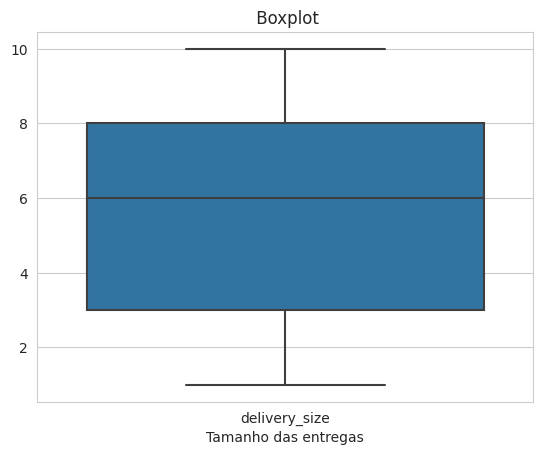

In [ ]:
with sns.axes_style('whitegrid'):
  grafico= sns.boxplot(data=deliveries_df[['delivery_size']])
  grafico.set(title=' Boxplot', xlabel= 'Tamanho das entregas')

O tamanho médio de uma encomenda a ser entregue é 6. A maior entrega a ser feita possui tamanho 10 e a menor é aproximadamente 1.

- Quais endereços possuem mais entregas as serem feitas?

In [ ]:
deliveries_per_address= deliveries_df[['delivery_lng', 'delivery_lat']].value_counts()
print(deliveries_per_address)

delivery_lng  delivery_lat
-47.892584    -15.817557      12
-47.753464    -15.747597      10
-48.054498    -16.021173      10
-47.827307    -15.676228      10
-47.929740    -15.797443      10
                              ..
-48.023727    -15.794955       1
-47.890202    -15.811924       1
-48.023722    -15.843453       1
-47.890203    -15.752084       1
-47.931306    -15.790876       1
Length: 291566, dtype: int64


Identificar e atuar nos locais com mais entregas a serem realizadas primeiro pode agilizar o processo de entregas da empresa como um todo. Além disso, os Hub's de distribuição não ficam sobrecarregados de encomendas a serem entregues.  

- Quantos locais de entrega possuem números registrados para identificação?

In [ ]:
number_address= deliveries_df[['hub_number']].value_counts()
print(number_address)

hub_number
lote 4/8      261319
dtype: int64


Somente há registros de números na região de Taguatinga. Isso pode dificultar a identificação dos estabelecimentos/residências de entrega deixando o processo de distribuição de encomendas mais lento.

- Quais ruas possuem um maior número de entregas a serem feitas?

In [ ]:
most_delivery_per_road= deliveries_df[['hub_road']].value_counts()
print(most_delivery_per_road)

hub_road
W1 Sul      304708
CSB 4/5     261319
Rua 7        70122
dtype: int64


Verificar quais ruas têm mais entregas a serem feitas auxilia na agilidade da logística de entrega